# Aufgabe 2

## Messen der Daten

Bei der zweiten Aufgabe, sollten wir die Resonanzkurve des Drehpendels bei einer Dämpfung messen, sowie die Phasenverschiebung zwischen der Anregung und Pendelscheibe. Da die Dämpfung über die Spule kommt und diese über den Strom am Channel 1 angesteuert wird, haben wir dort konstant 0.3 A eingestellt. Um herauszufinden, in welchem Bereich die Resonanzkurve circa ihren Peak hat, wurde zuerst in 1V Schritten zwischen 3V und 12V gemessen. Dabei ist aufgefallen, dass der Peak ungefähr bei 11V liegt, weshalb die eigentliche Messung zwischen 9V und 12V stattfand jeweils im Abstand von 0.1V.

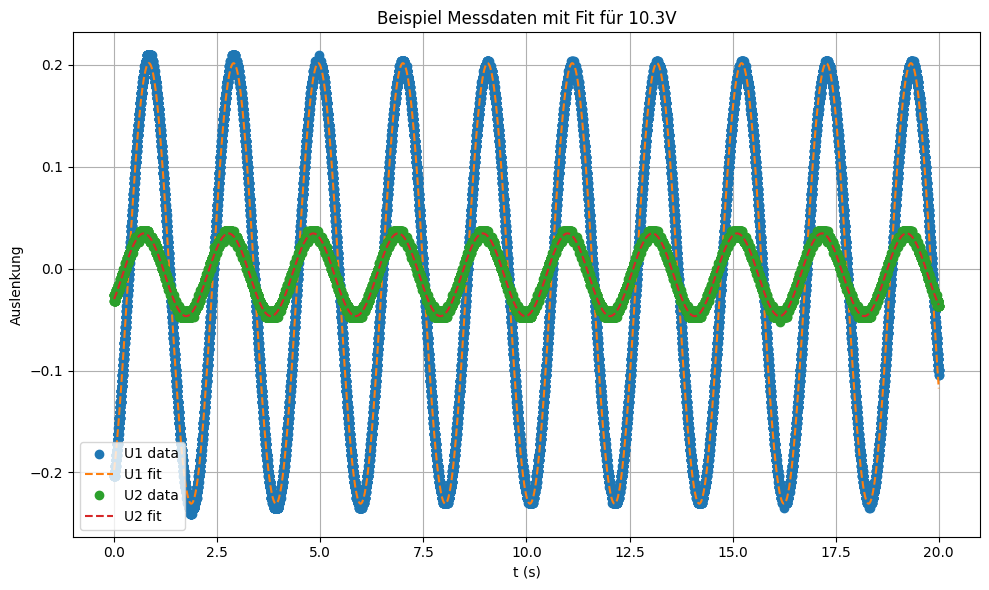

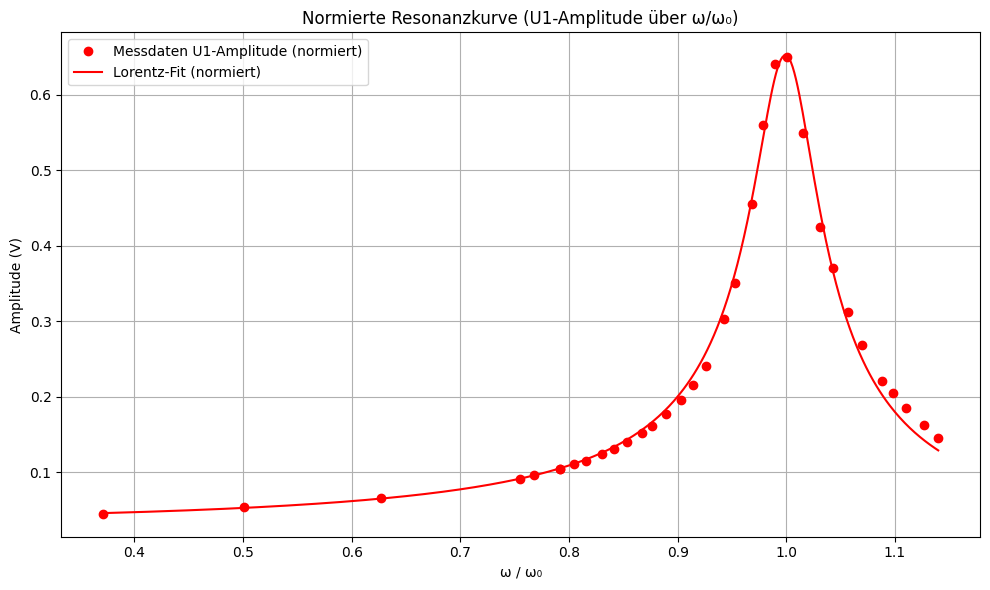

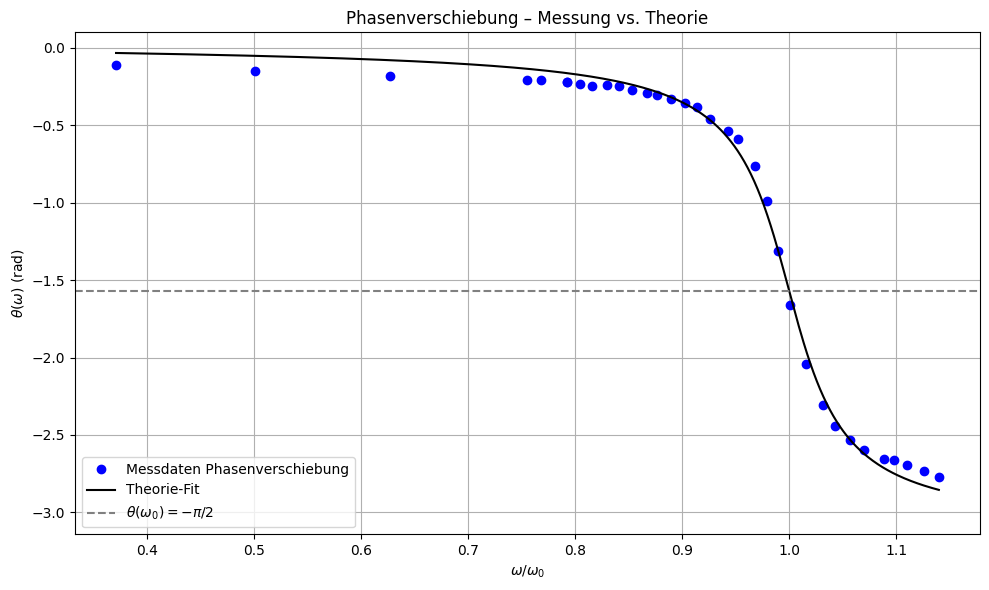

=== Resonanzkurve (U1-Amplitude) ===
A0 (Amplitude bei Resonanz): 0.442978 V
ω₀ (Eigenkreisfrequenz): 3.345119 rad/s
δ (Abklingkonstante): 0.101583 1/s
→ Resonanzfrequenz ω_R = sqrt(ω₀² - 2δ²) = 3.342033 rad/s

=== Phasenverschiebung (θ) ===
δ (Abklingkonstante aus Phase): 0.038729 1/s
→ Wendepunkt der Phase bei ω = ω₀, dort θ = -π/2


In [184]:
# | fig-cap:
# |     - "Beispiel Messdaten mit Fit für 10.3V"
# |     - "Normierte Resonanzkurve (U1-Amplitude über omega/omega_0)"
# |     - "Phasenverschiebung – Messung vs. Theorie"
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted

# Sinusfunktion mit Offset
def sinus_function(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset


# Lorentz-Funktion für Resonanzkurve
def lorentz_func(omega, A0, omega0, beta):
    return A0 / np.sqrt((omega0**2 - omega**2)**2 + (2*beta*omega)**2)


# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, omega_guess, phase_guess, offset_guess]
    params, params_covariance = curve_fit(
        sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    fitted_y = sinus_function(x_data, *params)
    return params, fitted_y

def phase_shift_theory(omega_ratio, beta):
    r = np.array(omega_ratio)
    arg = (2 * beta * r) / (1 - r**2)
    theta = np.arctan(arg)
    # +π für r > 1, um Sprung zu vermeiden
    theta = np.where(r > 1, theta + np.pi, theta)
    theta = np.where(np.isclose(r, 1.0), np.pi/2, theta)
    return -theta


# Ordnerpfad anpassen
filepath = "M10_Aufgabe_2_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
amplitudes_U2 = []
omegas_U2 = []
delta_t = []
phasen_diff = []
params_U1_Example = []
params_U2_Example = []
fitted_U1_Example = []
fitted_U2_Example = []
x_Example = 0
y_Example = 0
z_Example = 0

for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['t (s)', 'U1(V)', 'U2(V)']

    x = df['t (s)'].values
    y = df['U1(V)'].values
    z = df['U2(V)'].values

    if '10_3V_Aufgabe_2_daten.csv' in filename:
        paramsU2, fitted_U2 = fit_sinus(x, z)
        paramsU1 = [0.216, 3.06, -1.01, -0.0146]
        fitted_U1 = sinus_function(x, *paramsU1)
        params_U1_Example = paramsU1
        fitted_U1_Example = fitted_U1
        params_U2_Example = paramsU2
        fitted_U2_Example = fitted_U2
        x_Example = x
        y_Example = y
        z_Example = z
    else:
        paramsU1, fitted_U1 = fit_sinus(x, y)
        paramsU2, fitted_U2 = fit_sinus(x, z)

    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[1])
    amplitudes_U2.append(np.abs(paramsU2[0]))
    omegas_U2.append(paramsU2[1])


    # Fit-Parameter
    A1, omega1, phi1, _ = paramsU1
    A2, omega2, phi2, _ = paramsU2

    # Periodendauer (Durchschnitt)
    T = 2 * np.pi / ((omega1 + omega2) / 2)

    # t_max berechnen (nur für 1. Periode ab t=0)
    t_max_U1 = ((np.pi / 2) if A1 > 0 else (3 * np.pi / 2)) - phi1
    t_max_U1 = t_max_U1 / omega1 % T

    t_max_U2 = ((np.pi / 2) if A2 > 0 else (3 * np.pi / 2)) - phi2
    t_max_U2 = t_max_U2 / omega2 % T

    # Delta-t auf Bereich [-T/2, +T/2] bringen:
    delta = t_max_U2 - t_max_U1
    if delta > T/2:
        delta -= T
    elif delta < -T/2:
        delta += T

    delta_t.append(delta)

    phasen_dif = omega1 * delta
    phasen_diff.append(phasen_dif)

    #plt.figure(figsize=(10, 6))
    #plt.plot(x, y, 'o', label='U1 data')
    #plt.plot(x, fitted_U1, '--', label='U1 fit')
    #plt.plot(x, z, 'o', label='U2 data')
    #plt.plot(x, fitted_U2, '--', label='U2 fit')
    #plt.xlabel('t (s)')
    #plt.ylabel('Auslenkung')
    #plt.title(filename)
    #plt.legend()
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

    


# Plotten
plt.figure(figsize=(10, 6))
plt.plot(x_Example, y_Example, 'o', label='U1 data')
plt.plot(x_Example, fitted_U1_Example, '--', label='U1 fit')
plt.plot(x_Example, z_Example, 'o', label='U2 data')
plt.plot(x_Example, fitted_U2_Example, '--', label='U2 fit')
plt.xlabel('t (s)')
plt.ylabel('Auslenkung')
plt.title('Beispiel Messdaten mit Fit für 10.3V')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Arrays und Sortierung
omegas_U2 = np.array(omegas_U2)
amplitudes_U1 = np.array(amplitudes_U1)
sorted_indices = np.argsort(omegas_U2)
omegas_U2 = omegas_U2[sorted_indices]
amplitudes_U1 = amplitudes_U1[sorted_indices]
delta_t = np.array(delta_t)[sorted_indices]
delta_t = - delta_t  # Vorzeichen umkehren
phasen_diff = np.array(phasen_diff)[sorted_indices]

# Fit der Resonanzkurve U1
p0_amp = [np.max(amplitudes_U1), omegas_U2[np.argmax(amplitudes_U1)], 0.1]
params_amp, _ = curve_fit(lorentz_func, omegas_U2, amplitudes_U1, p0=p0_amp, maxfev=10000)

fit_omegas = np.linspace(np.min(omegas_U2), np.max(omegas_U2), 500)
fit_amplitudes = lorentz_func(fit_omegas, *params_amp)


# Normierte x-Werte
omega0 = params_amp[1]
beta = params_amp[2]

omega_ratio_data = omegas_U2 / omega0
omega_ratio_fit = fit_omegas / omega0




p0_phase = [beta]  # Startwert aus dem Lorentz-Fit
params_phase, _ = curve_fit(
    phase_shift_theory,
    omega_ratio_data,
    phasen_diff,
    p0=p0_phase,
    bounds=(0.001, 1.0),
    maxfev=10000
)


plt.figure(figsize=(10, 6))
plt.plot(omega_ratio_data, amplitudes_U1, 'ro', label='Messdaten U1-Amplitude (normiert)')
plt.plot(omega_ratio_fit, fit_amplitudes, 'r-', label='Lorentz-Fit (normiert)')
plt.xlabel('ω / ω₀')
plt.ylabel('Amplitude (V)')
plt.title('Normierte Resonanzkurve (U1-Amplitude über ω/ω₀)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fit_phase_curve = phase_shift_theory(omega_ratio_fit, *params_phase)

plt.figure(figsize=(10, 6))
plt.plot(omega_ratio_data, phasen_diff, 'bo', label='Messdaten Phasenverschiebung')
plt.plot(omega_ratio_fit, fit_phase_curve, 'k-', label='Theorie-Fit')
plt.axhline(-np.pi/2, color='gray', linestyle='--', label=r'$\theta(\omega_0) = -\pi/2$')
plt.xlabel(r'$\omega / \omega_0$')
plt.ylabel(r'$\theta(\omega)$ (rad)')
plt.title('Phasenverschiebung – Messung vs. Theorie')
plt.ylim(-np.pi, 0.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


import math

# Resonanzkurven-Parameter
A0, omega0, beta = params_amp
print("=== Resonanzkurve (U1-Amplitude) ===")
print(f"A0 (Amplitude bei Resonanz): {A0:.6f} V")
print(f"ω₀ (Eigenkreisfrequenz): {omega0:.6f} rad/s")
print(f"δ (Abklingkonstante): {beta:.6f} 1/s")
print(f"→ Resonanzfrequenz ω_R = sqrt(ω₀² - 2δ²) = {math.sqrt(omega0**2 - 2 * beta**2):.6f} rad/s")

# Phasenverschiebung-Parameter
delta_phase = params_phase[0]
print("\n=== Phasenverschiebung (θ) ===")
print(f"δ (Abklingkonstante aus Phase): {delta_phase:.6f} 1/s")
print("→ Wendepunkt der Phase bei ω = ω₀, dort θ = -π/2")



Alle 30 Datensätze können als Plot angegeben werden und für alle wurde eine Fit-Funktion gefunden, allerdings wurde aus Platzgründen nur ein Beispiel im Protkoll angezeigt. Resonanzkurve und Phasenverschiebung wurden ebenfalls geplotet und als Bild angehängt, wobei die Parameter für die Fitfunktion dazu ausgeben wurden.